In [1]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo 
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as colors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.exceptions import ConvergenceWarning
import warnings

UCI dataset Differentiated Thyroid Cancer Recurrence (id=915)

Originally, contains 16 categorical parameters relating to the individuals' health. But after creating dummies for each (and dropping one from each category), there are 40 binary parameters.
Number of observations: 383

Target: binary (whether cancer recurred or not)



In [2]:
# fetch dataset
data_id=915
data_frame = fetch_ucirepo(id=data_id) 
  
# data (as pandas dataframes) 
X = data_frame.data.features
y = data_frame.data.targets
df = pd.concat([X, y], axis=1)
df = pd.get_dummies(df, drop_first=True, dtype=int)
df = df.to_numpy()
M = df[:, :-1]
y = df[:, -1]
num_obs, params = M.shape

In [3]:
rng=np.random.default_rng(51)

def resort_data(num_pts, num_params, M, y):
    '''
    num_pts: How many data points are needed (size of training data)
    M: Entire data matrix (including y-values)'''

    # Reorder M by observation so that logit doesn't break
    y_T = np.zeros(num_pts)
    while not np.any(y_T != y_T[0]):
        indices = rng.choice(np.arange(num_obs), size=num_pts, replace=False)
        y_T = y[indices]

    M_new = np.concatenate((M[indices, :], np.delete(M, indices, axis=0)))

    # Randomly sort parameters
    param_ordering = rng.permutation(params)
    M_new = M_new[:, param_ordering]

    # Breaking down the resorted matrix
    M_TM = M_new[:num_pts, :num_params]
    M_TU = M_new[:num_pts, num_params:]
    M_PM = M_new[num_pts:, :num_params]
    M_PU = M_new[num_pts:, num_params:]
    y_P = np.delete(y, indices)
    y_new = np.concatenate((y_T, y_P))
    return M_new, M_TM, M_TU, M_PM, M_PU, y_T, y_P, y_new

In [4]:
error_matrix = []
# y_value_labels = []
# x_value_labels = []

# Compute log loss (risk)
for j in range(2,num_obs,15):
    error_matrix.append([])
    # y_value_labels.append(j)
    for i in range(1,params):
        listy = []
        for k in range(10):
            # model=LogisticRegression(C=np.inf,solver='lbfgs')
            M_new, M_TM, M_TU, M_PM, M_PU, y_T, y_P, y_new = resort_data(j, i, M, y)
            # model.fit(M_TM, y_T)
            # y_hat = model.predict_proba(np.concatenate((M_TM,M_PM)))[:, 1]
            # error = log_loss(y_new, y_hat, labels=[0,1])
            # listy.append(error)
        # listy = np.array(listy)
        # error_matrix[-1].append(np.mean(listy))
    
# error_matrix = np.array(error_matrix)

# Clip to 95th percentile
# p95 = np.percentile(error_matrix, 95)
# error_matrix = np.clip(error_matrix, a_min=0, a_max=p95)

# Plotting it
# fig, ax = plt.subplots()
# yeet=ax.imshow(error_matrix, aspect='auto', origin='lower', extent = [1,params,2,num_obs])
# plt.xlabel("Number of Parameters")
# plt.ylabel("Number of Data Points")
# plt.title('Risk for Thyroid Cancer Dataset (id=915) (Log Loss) Heatmap')
# fig.colorbar(yeet,label='Risk (Log Loss Function)')
# plt.plot([1,min(num_obs,params)],[1,min(num_obs,params)],'--',color='red')
# plt.ylim((2,num_obs))
# plt.xlim((1,params))
# plt.tight_layout()
# # plt.savefig(f'logit_risk_{data_id}-2.png',dpi=400)
# plt.show()

Below, I do the exact same thing but use MSE instead of cross entropy loss.

c:\Users\lando\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\lando\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

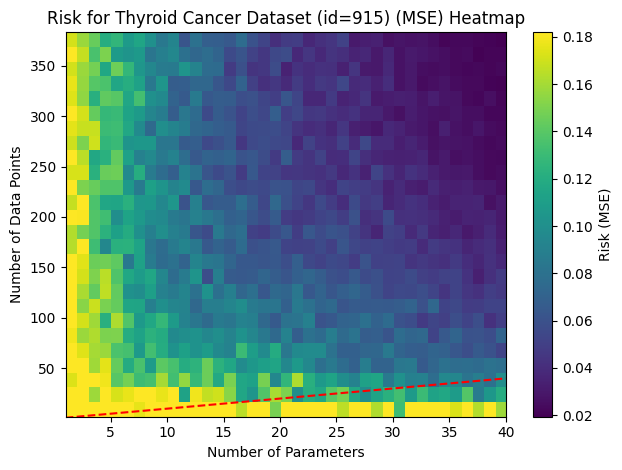

In [5]:
error_matrix = []
# y_value_labels = []
# x_value_labels = []

# Compute log loss (risk)
for j in range(2,num_obs,15):
    error_matrix.append([])
    # y_value_labels.append(j)
    for i in range(1,params):
        listy = []
        for k in range(10):
            model=LogisticRegression(C=np.inf,solver='lbfgs')
            M_new, M_TM, M_TU, M_PM, M_PU, y_T, y_P, y_new = resort_data(j, i, M, y)
            model.fit(M_TM, y_T)
            y_hat = model.predict_proba(np.concatenate((M_TM,M_PM)))[:, 1]
            error = np.mean((y_new-y_hat)**2)
            listy.append(error)
        listy = np.array(listy)
        error_matrix[-1].append(np.mean(listy))
    
error_matrix = np.array(error_matrix)

# Clip to 95th percentile
p95 = np.percentile(error_matrix, 95)
error_matrix = np.clip(error_matrix, a_min=0, a_max=p95)

# Plotting it
fig, ax = plt.subplots()
yeet=ax.imshow(error_matrix, aspect='auto', origin='lower', extent = [1,params,2,num_obs])
plt.xlabel("Number of Parameters")
plt.ylabel("Number of Data Points")
plt.title('Risk for Thyroid Cancer Dataset (id=915) (MSE) Heatmap')
fig.colorbar(yeet,label='Risk (MSE)')
plt.plot([1,min(num_obs,params)],[1,min(num_obs,params)],'--',color='red')
plt.ylim((2,num_obs))
plt.xlim((1,params))
plt.tight_layout()
plt.savefig(f'logit_risk_{data_id}-MSE.png',dpi=400)
plt.show()